In [ ]:
import rasterio
import rasterio.mask
import r5py as r5
import h3
import geopandas as gpd
from shapely.geometry import Polygon, box
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
from pyrosm import OSM
import numpy as np
from pyrosm.data import sources
from pyrosm import get_data
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
import wkls
from reusable import *

### **Boundaries and setup**

In [ ]:
osm_path = r"sample_cities/milan/milan.osm.pbf"
gtfs_path = r"sample_cities/milan/gtfs_fixed_fixed.zip"
pop_path = r"sample_cities/milan/ita_general_2020_geotiff/ita_general_2020.tif"
bound_path = r"sample_cities/milan/milan.geojson"

In [3]:
osm = OSM(osm_path)
boundaries = osm.get_boundaries()

In [4]:
tn = r5.TransportNetwork(osm_path, gtfs=gtfs_path)

In [5]:
local_crs = boundaries.estimate_utm_crs()
city_proj = boundaries.to_crs(local_crs)

<Axes: >

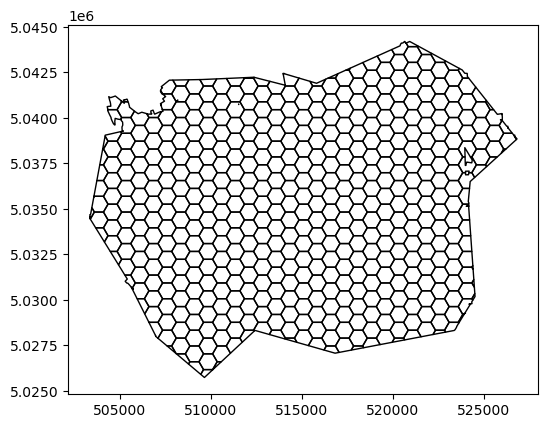

In [6]:
grid = create_hex_grid(city_proj, 500)
grid.plot(edgecolor='black', facecolor='none')

#### **Populating the grid**

Raster total population:  1,548,018
Hex grid total population: 1,547,471
Coverage: 100.0%


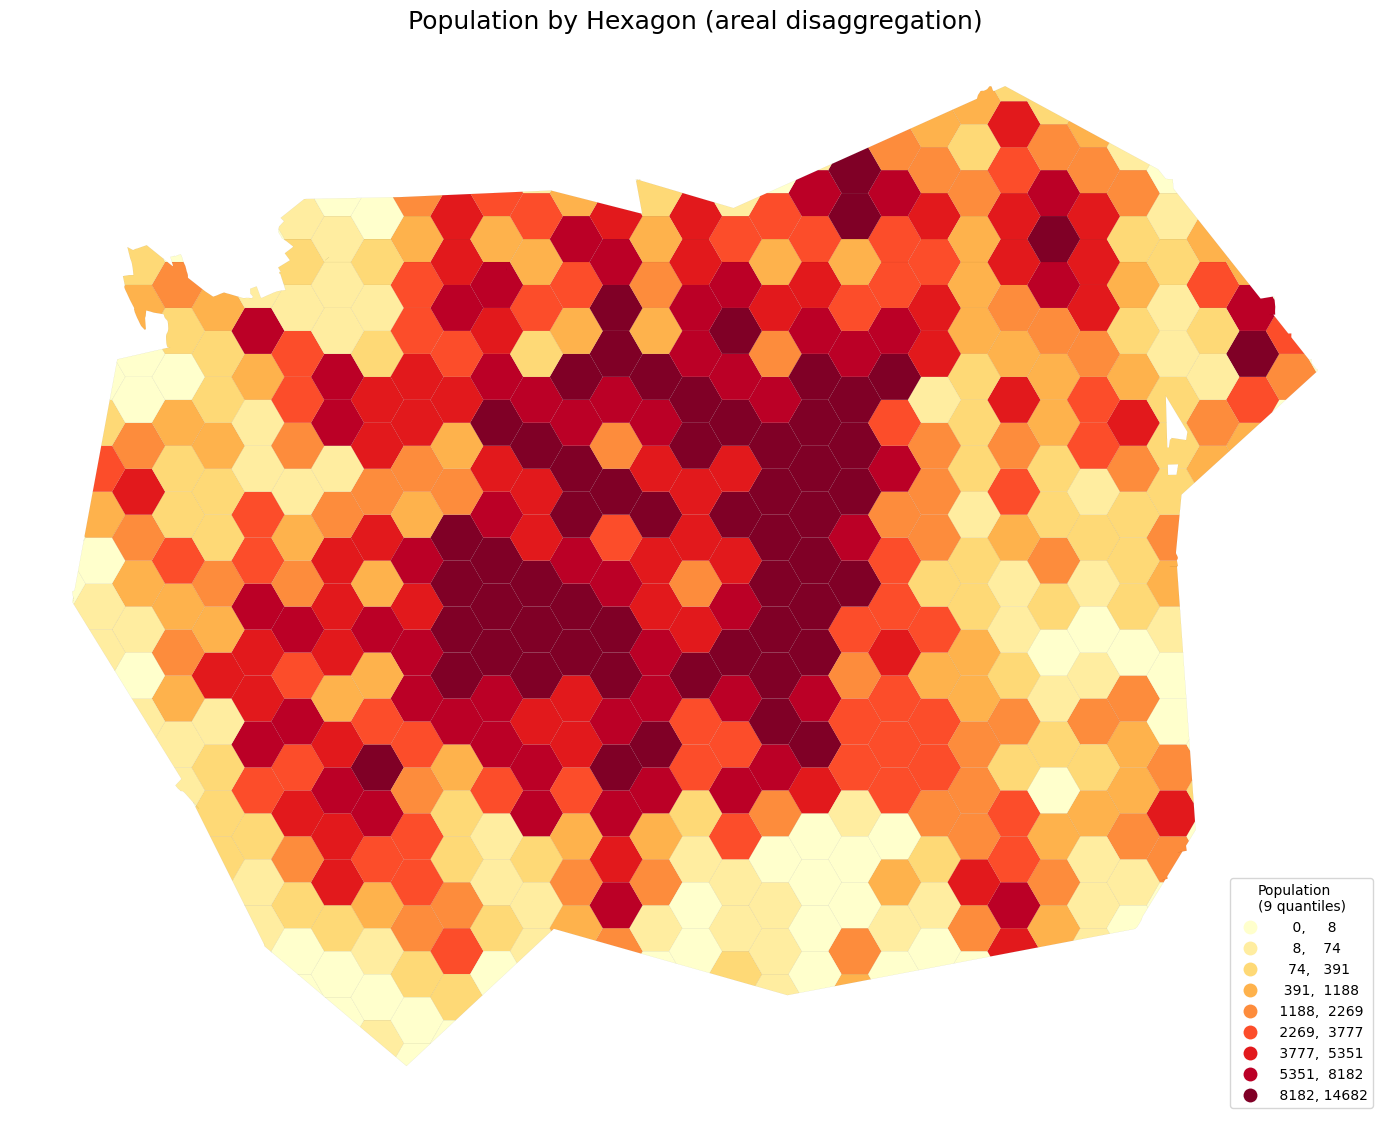

In [7]:
grid_pop = assign_population_to_grid(pop_path, grid, plot=True)

In [8]:
result_geo = build_city_geojson(
    grid=grid,
    grid_pop=grid_pop,
    osm=osm,
    tn=tn,
    output_path="data/milan_scores.geojson",
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=25,
    beta=0.0277,
    gravity_normalisation=100,
)

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\r5py\r5\regional_task.py:205: RuntimeWarning: The currently loaded GTFS data sets do not define any services on 2026-05-05.
  warnings.warn(


City-wide baseline distribution:
  count_community: 0.046
  count_education: 0.077
  count_essential_services: 0.118
  count_food_and_drink: 0.659
  count_healthcare: 0.086
  count_shelter: 0.015


#### **Origins**

In [12]:
origins = create_origins(grid, grid_pop)
origins.head(5)

,geometry,id,population
0,POINT (9.23067 45.39954),0,472.469829
1,POINT (9.24044 45.40196),1,2.710131
2,POINT (9.25944 45.40336),2,4.403294
3,POINT (9.28822 45.40717),3,10.764087
4,POINT (9.26922 45.40577),4,3853.894362


#### **Destinations (POIs)**

In [13]:
destinations = create_POIs(osm, summary=True)

Total amenities: 14470

By type:
amenity class
food_and_drink        6623
essential_services    1187
healthcare             885
education              861
drinking_water         861
community              506
toilets                352
clock                  345
bicycle_rental         321
fuel                   286


#### **Results and Visualisation**

Define categories of interest among the amenity classes to measure

In [14]:
categories = ['food_and_drink','shelter','essential_services','education','healthcare','community']
essentials = destinations[destinations['amenity class'].isin(categories)]

Compute travel time matrix between all origins and points of interest, deifining threshold for max. travel time and modes of transport

In [15]:
travel_time_matrix = r5.TravelTimeMatrix(
    tn,
    origins=origins,
    destinations=essentials,
    transport_modes=[r5.TransportMode.TRANSIT, r5.TransportMode.WALK],
    max_time=timedelta(minutes=20) #CUTOFF
)

Calculate score for basic metrics (minimum travel time, basic counts (no gravity), weighted counts (gravity))

In [16]:
min_tt_wide = min_travel_time(travel_time_matrix, essentials)

In [17]:
no_gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0)

In [18]:
gravity = compute_gravity_scores(travel_time_matrix, destinations=essentials, beta=0.0644)

Adjusting for population & diversity metric

In [19]:
pop_weighed = weight_pop(gravity, origins, score_cols=["gravity_food_and_drink"], normalisation=1000)

In [20]:
cols = [x for x in no_gravity.columns if x not in ['from_id','avg_gravity']]
diversity = compute_diversity_scores(no_gravity, count_cols=cols)

City-wide baseline distribution:
  gravity_community: 0.039
  gravity_education: 0.061
  gravity_essential_services: 0.131
  gravity_food_and_drink: 0.673
  gravity_healthcare: 0.083
  gravity_shelter: 0.013


### **Result Plotting**

In [21]:
gravity = merge_geometry(gravity, grid=grid)
res = merge_geometry(min_tt_wide, grid)
pop_weighed = merge_geometry(pop_weighed, grid)
no_gravity = merge_geometry(no_gravity, grid=grid)
diversity = merge_geometry(diversity, grid=grid)

In [22]:
def plot_hex_score(results_geo, score_col, from_id_col="from_id", scheme="Quantiles",
                   k=9, cmap="viridis", title=None, figsize=(14, 12),
                   legend_fmt="{:.1f}", ax=None, show=True):

    n_missing = results_geo[score_col].isna().sum()
    if n_missing > 0:
        print(f"Note: {n_missing} hexes have NaN for '{score_col}' and will appear grey.")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    results_geo.plot(
        column=score_col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        linewidth=0.02,
        edgecolor="none",
        missing_kwds={"color": "lightgrey", "label": "No data"},
        legend_kwds={
            "loc": "upper left",
            "bbox_to_anchor": (1.02, 1),
            "fmt": legend_fmt
        },
        ax=ax
    )

    ax.set_title(title if title else score_col.replace("_", " ").title(), fontsize=18)
    ax.set_axis_off()

    if show:
        plt.tight_layout()
        plt.show()

d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 16.
  self.bins = quantile(y, k=k)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 17.
  self.bins = quantile(y, k=k)


Note: 125 hexes have NaN for 'min_tt_food_and_drink' and will appear grey.


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting k to 15.
  self.bins = quantile(y, k=k)


Note: 106 hexes have NaN for 'avg_tt' and will appear grey.


d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\hp\Documents\Scripts\r5py\.conda\Lib\site-packages\mapclassify\classifiers.py:1767: UserWarning: Not enough unique values in array to form 20 classes. Setting

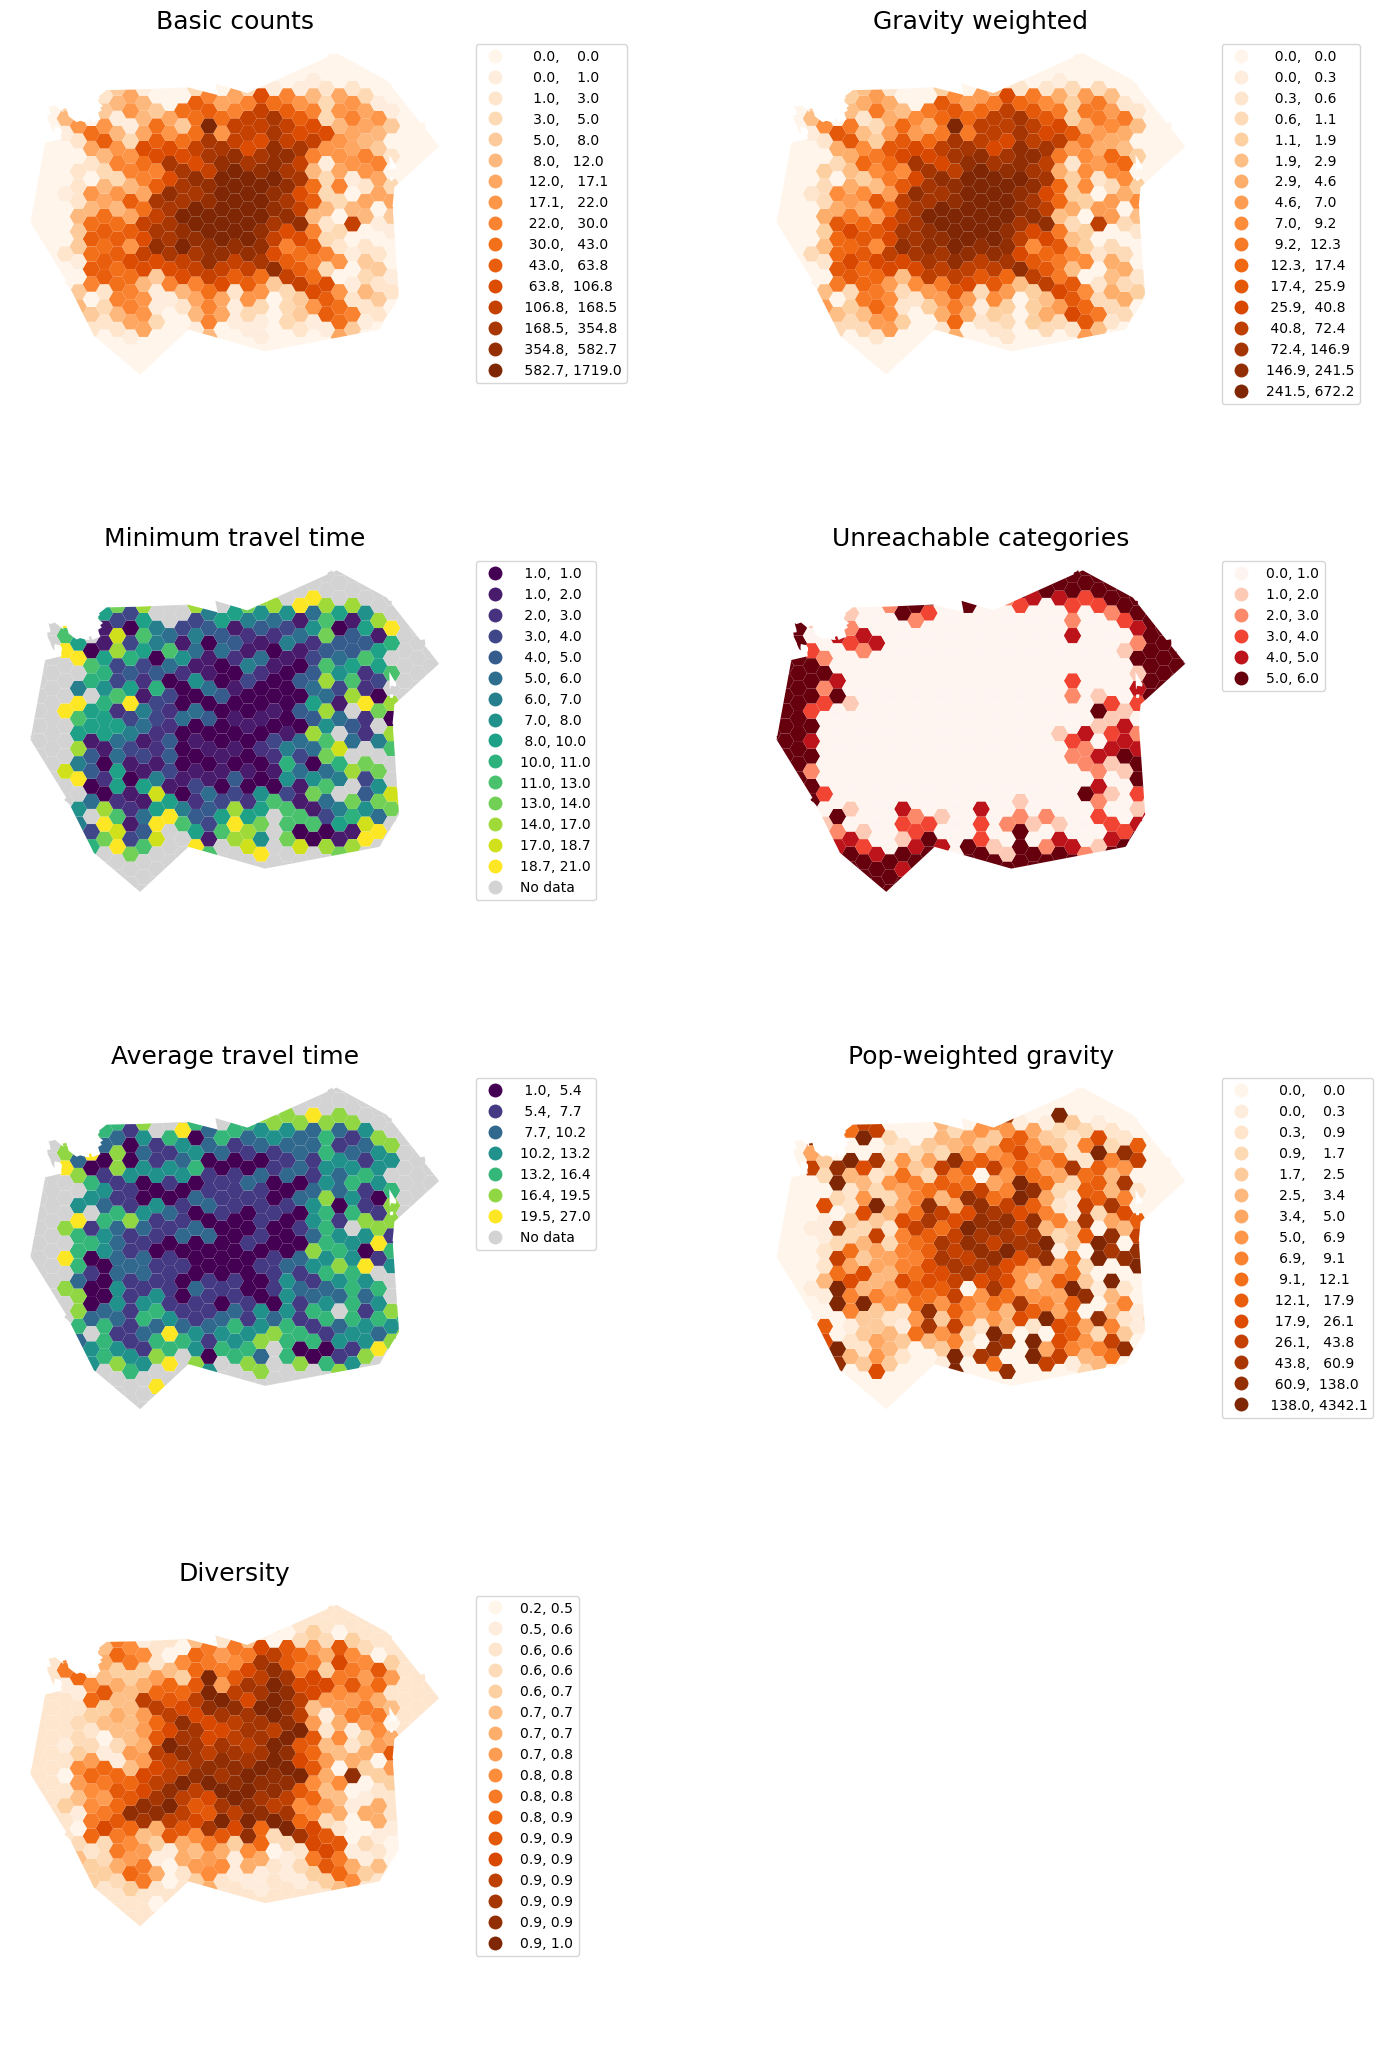

In [23]:
fig = plt.figure(figsize=(18, 26))
gs = fig.add_gridspec(
    nrows=8, ncols=2,
    height_ratios=[12, 1, 12, 1, 12, 1, 12, 1],
    hspace=0.35, wspace=0.15
)

plots = [
    (no_gravity, "gravity_food_and_drink", "Basic counts", "Oranges", "Quantiles", 20),
    (gravity, "gravity_food_and_drink", "Gravity weighted", "Oranges", "Quantiles", 20),
    (res, "min_tt_food_and_drink", "Minimum travel time", "viridis", "Quantiles", 20),
    (res, "n_unreachable_categories", "Unreachable categories", "Reds", "EqualInterval", 6),
    (res, "avg_tt", "Average travel time", "viridis", "NaturalBreaks", 7),
    (pop_weighed, "gravity_food_and_drink_per_1000", "Pop-weighted gravity", "Oranges", "Quantiles", 20),
    (diversity, "city_similarity", "Diversity", "Oranges", "Quantiles", 20),
]

for i, (gdf, col, ttl, cmap, scheme, k) in enumerate(plots):
    row = (i // 2) * 2
    col_idx = i % 2

    ax = fig.add_subplot(gs[row, col_idx])

    plot_hex_score(
        gdf,
        score_col=col,
        cmap=cmap,
        scheme=scheme,
        k=k,
        title=ttl,
        ax=ax,
        show=False
    )

if len(plots) % 2 == 1:
    fig.add_subplot(gs[6, 1]).axis("off")
    fig.add_subplot(gs[7, 1]).axis("off")

plt.tight_layout()
fig.savefig("turin_results.png", dpi=300, bbox_inches="tight")